# New College Dataset data loading

This notebook inspects the raw New College short experiment, converts IMU streams to synchronized `IMUData` objects, estimates pairwise LiDAR `SE(3)` shifts, and plots timing and derived rates.

In [1]:
# Configuration: keep all notebook knobs here.
from pathlib import Path

DATASET_ROOT = Path('/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16')
TARGET_IMU_FREQUENCY_HZ = 100.0
MAX_IMU_FILES = None

LIDAR_VOXEL_SIZE_M = 0.5
LIDAR_MAX_CORRESPONDENCE_DISTANCE_M = 1.5
LIDAR_MAX_ITERATIONS = 50
LIDAR_MAX_SCANS = None
LIDAR_SCAN_PERIOD_S = None
EXTRACT_LIDAR_IF_NEEDED = True

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_ROOT = PROJECT_ROOT / 'src'

In [2]:
import sys

import matplotlib.pyplot as plt
import numpy as np

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import kaist_dataset, calib_observability
from kaist_dataset import load_imus, load_lidar_relative_poses, lidar
from kaist_dataset.imu import discover_imu_files
from kaist_dataset.lidar import discover_lidar_archives, discover_lidar_scans
from kaist_dataset.plotting import plot_imu_streams, plot_lidar_rates, plot_sensor_timestamps
from transform import se3_to_angvels, se3_to_velocities

## Discover raw files

In [4]:
imu_files = discover_imu_files(DATASET_ROOT)
lidar_archives = discover_lidar_archives(DATASET_ROOT / "urban16_data/urban16/sensor_data/VLP_left")
lidar_scans_before_extract = discover_lidar_scans(DATASET_ROOT / "urban16_data/urban16/sensor_data/VLP_left", extract_if_needed=False)

print(f'IMU candidate files: {len(imu_files)}')
for path in imu_files[:10]:
    print('  ', path)

print(f'LiDAR zip archives: {len(lidar_archives)}')
for path in lidar_archives[:10]:
    print('  ', path)

print(f'Already extracted scans: {len(lidar_scans_before_extract)}')

IMU candidate files: 1
   /mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16/urban16_data/urban16/sensor_data/xsens_imu.csv
LiDAR zip archives: 0
Already extracted scans: 44535


## Load and resample IMU streams

In [5]:
imu_streams = load_imus(
    DATASET_ROOT,
    target_frequency_hz=TARGET_IMU_FREQUENCY_HZ,
    max_files=MAX_IMU_FILES,
)

for name, imu in imu_streams.items():
    print(
        name,
        imu.timestamps_s.shape,
        imu.accel_mps2.shape,
        imu.gyro_radps.shape,
        f'{imu.frequency_hz:.1f} Hz',
    )

sensor_data_xsens_imu (449195,) (449195, 3) (449195, 3) 100.0 Hz


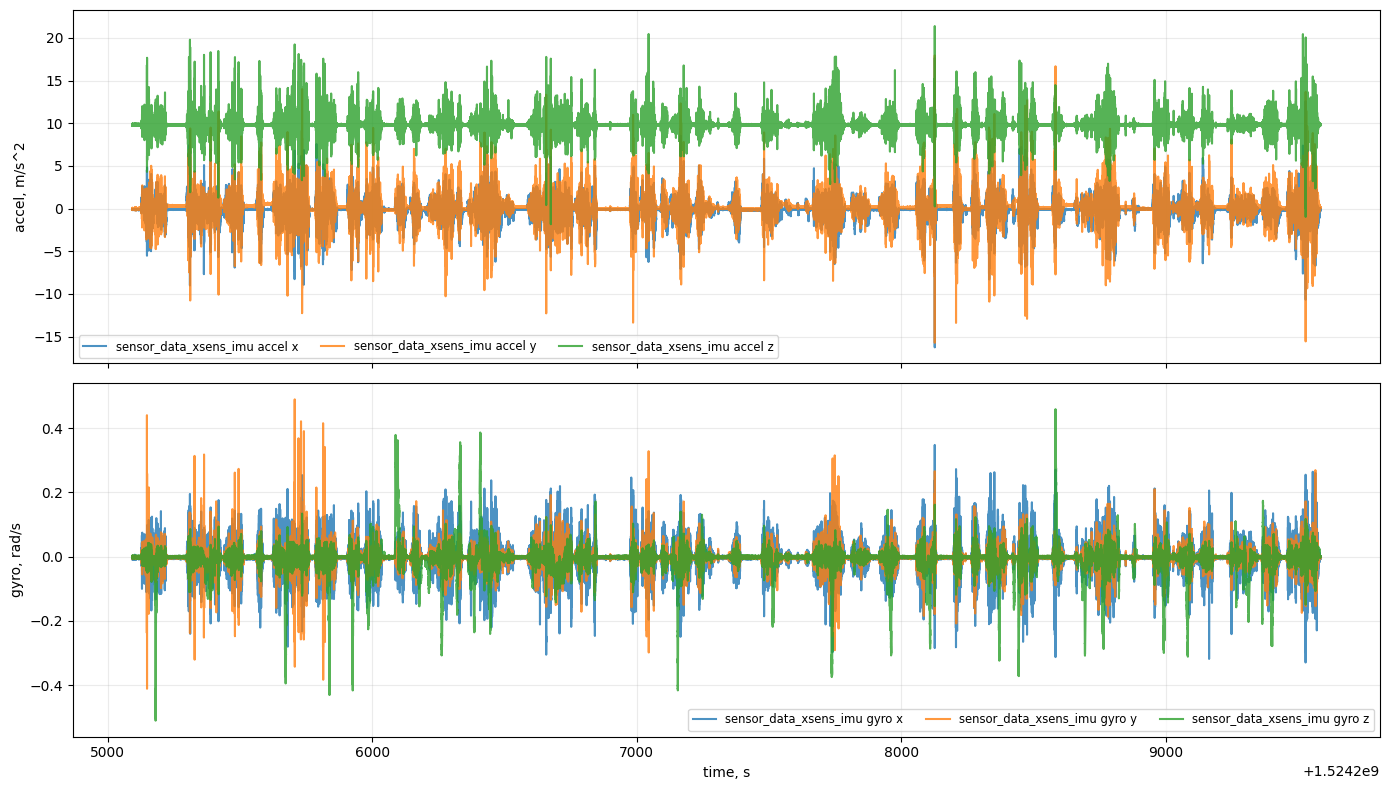

In [6]:
for i, (key, value) in enumerate(imu_streams.items()):
    fig, axes = plot_imu_streams({key:value})
    plt.show()

## Estimate LiDAR relative poses

In [7]:
lidar_data = load_lidar_relative_poses(
    DATASET_ROOT / "urban16_data/urban16/sensor_data/VLP_left",
    voxel_size_m=LIDAR_VOXEL_SIZE_M,
    max_correspondence_distance_m=LIDAR_MAX_CORRESPONDENCE_DISTANCE_M,
    max_iterations=LIDAR_MAX_ITERATIONS,
    max_scans=LIDAR_MAX_SCANS,
    scan_period_s=LIDAR_SCAN_PERIOD_S,
    extract_if_needed=False,
    number_of_workers=24,
)

print('LiDAR interval timestamps:', lidar_data.timestamps_s.shape)
print('LiDAR relative poses:', lidar_data.relative_poses_se3.shape)
print('ICP fitness median:', np.median(lidar_data.fitness) if lidar_data.fitness is not None else None)
print('ICP RMSE median:', np.median(lidar_data.inlier_rmse) if lidar_data.inlier_rmse is not None else None)

LiDAR ICP chunks: 100%|██████████| 24/24 [06:51<00:00, 17.16s/it]  


LiDAR interval timestamps: (44534,)
LiDAR relative poses: (44534, 4, 4)
ICP fitness median: 0.9739758247194423
ICP RMSE median: 0.3881406192732014


In [8]:
lidar_data.timestamps_s

array([1.52420509e+09, 1.52420509e+09, 1.52420509e+09, ...,
       1.52420958e+09, 1.52420958e+09, 1.52420958e+09])

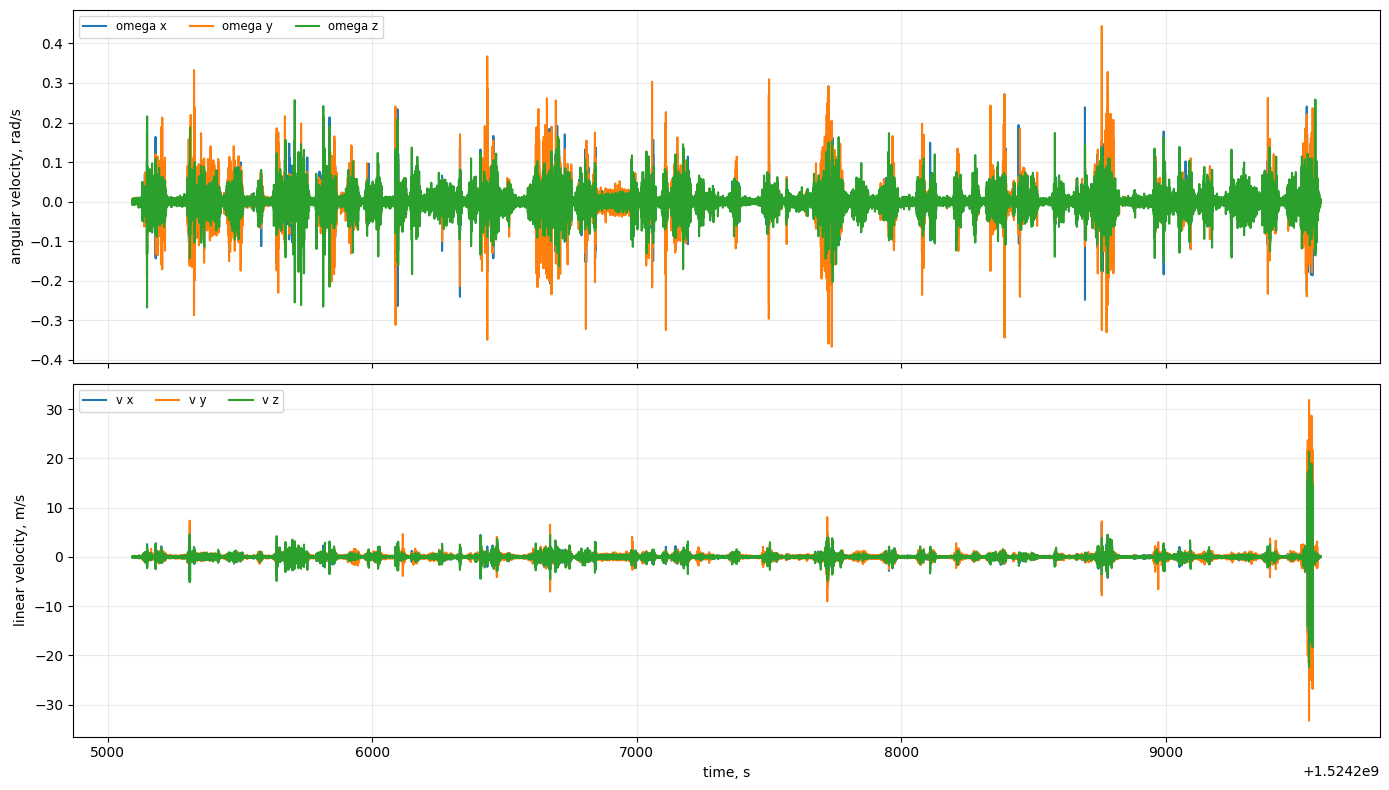

In [14]:
velocity_timestamps = lidar_data.scan_timestamps_s if lidar_data.scan_timestamps_s is not None else lidar_data.timestamps_s
lidar_angvel_radps = se3_to_angvels(lidar_data.relative_poses_se3, velocity_timestamps[:-1])
lidar_velocity_mps = se3_to_velocities(lidar_data.relative_poses_se3, velocity_timestamps[:-1])
lidar_angvel_radps = np.append(lidar_angvel_radps, [lidar_angvel_radps[-1]], axis=0)
lidar_velocity_mps = np.append(lidar_velocity_mps, [lidar_velocity_mps[-1]], axis=0)

fig, axes = plot_lidar_rates(lidar_data, lidar_angvel_radps, lidar_velocity_mps)
plt.show()

## Compare IMU and LiDAR timestamps

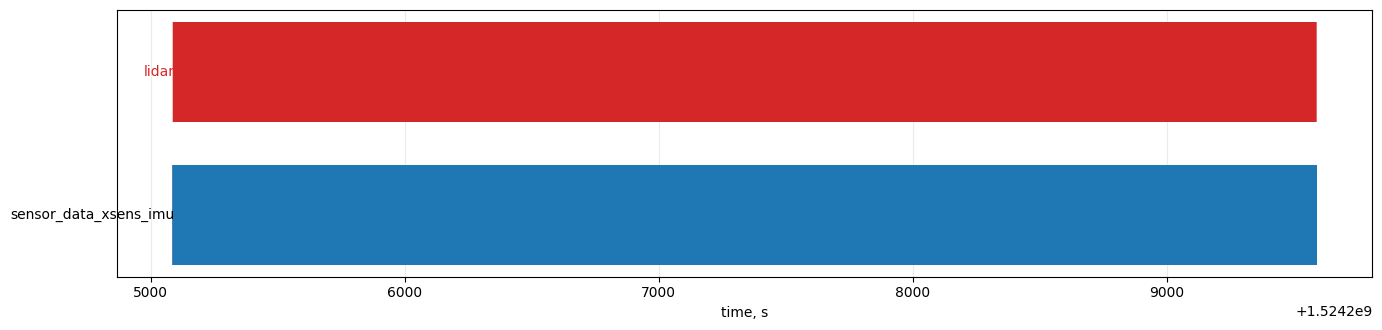

In [15]:
fig, axis = plot_sensor_timestamps(imu_streams, lidar_data)
plt.show()

## Validation checks

In [16]:
assert imu_streams, 'No IMU streams were loaded.'
for name, imu in imu_streams.items():
    assert np.all(np.isfinite(imu.timestamps_s)), name
    assert np.all(np.diff(imu.timestamps_s) > 0), name
    assert imu.accel_mps2.shape == (imu.timestamps_s.size, 3), name
    assert imu.gyro_radps.shape == (imu.timestamps_s.size, 3), name

assert lidar_data.relative_poses_se3.ndim == 3
assert lidar_data.relative_poses_se3.shape[1:] == (4, 4)
assert lidar_angvel_radps.shape == (lidar_data.relative_poses_se3.shape[0], 3)
assert lidar_velocity_mps.shape == (lidar_data.relative_poses_se3.shape[0], 3)

print('Validation passed.')

Validation passed.


# Save lidar data

In [17]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd


def _json_compatible(value: Any) -> Any:
    """Convert common NumPy and path objects into JSON-compatible values.

    Args:
        value: Arbitrary metadata value.

    Returns:
        A value accepted by ``json.dumps``.

    Raises:
        TypeError: If the value cannot be represented in JSON.
    """
    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, set):
        return list(value)

    raise TypeError(
        f"Object of type {type(value).__name__} is not JSON serializable"
    )


def save_lidar_data_csv(
    lidar_data: lidar.LidarData,
    filepath: str | Path,
) -> Path:
    """Save a ``LidarData`` entity into one CSV file without scan paths.

    Each row represents one relative-pose interval between consecutive scans.
    The original ``N + 1`` scan timestamps are stored as start/end timestamp
    pairs and can therefore be reconstructed from ``N`` interval rows.

    Shared metadata is serialized as JSON in the final column of the first row.
    The remaining rows leave that column empty.

    Args:
        lidar_data: LiDAR data containing interval timestamps, relative poses,
            scan timestamps, ICP fitness, RMSE, and metadata.
        filepath: Destination CSV path.

    Returns:
        Path to the saved CSV file.

    Raises:
        ValueError: If fields have inconsistent dimensions, contain non-finite
            values, or contain no relative-pose intervals.
    """
    output_path = Path(filepath).expanduser()
    output_path.parent.mkdir(parents=True, exist_ok=True)

    interval_timestamps = np.asarray(
        lidar_data.timestamps_s,
        dtype=float,
    ).reshape(-1)
    relative_poses = np.asarray(
        lidar_data.relative_poses_se3,
        dtype=float,
    )
    scan_timestamps = np.asarray(
        lidar_data.scan_timestamps_s,
        dtype=float,
    ).reshape(-1)
    fitness = np.asarray(
        lidar_data.fitness,
        dtype=float,
    ).reshape(-1)
    inlier_rmse = np.asarray(
        lidar_data.inlier_rmse,
        dtype=float,
    ).reshape(-1)

    number_of_intervals = interval_timestamps.size

    ##################################################
    # Validate the interval and scan sequence
    ##################################################

    if number_of_intervals == 0:
        raise ValueError(
            "lidar_data must contain at least one relative-pose interval"
        )

    if relative_poses.shape != (number_of_intervals, 4, 4):
        raise ValueError(
            "relative_poses_se3 must have shape (N, 4, 4), where "
            "N is the number of interval timestamps"
        )

    if scan_timestamps.shape != (number_of_intervals + 1,):
        raise ValueError(
            "scan_timestamps_s must have shape (N + 1,)"
        )

    if fitness.shape != (number_of_intervals,):
        raise ValueError("fitness must have shape (N,)")

    if inlier_rmse.shape != (number_of_intervals,):
        raise ValueError("inlier_rmse must have shape (N,)")

    arrays_to_check = (
        interval_timestamps,
        relative_poses,
        scan_timestamps,
        fitness,
        inlier_rmse,
    )
    if not all(np.all(np.isfinite(array)) for array in arrays_to_check):
        raise ValueError("lidar_data contains non-finite numerical values")

    ##################################################
    # Serialize the shared metadata
    ##################################################

    metadata_json = json.dumps(
        dict(lidar_data.metadata),
        default=_json_compatible,
        ensure_ascii=False,
        separators=(",", ":"),
    )

    pose_columns = [
        f"T_{row}{column}"
        for row in range(4)
        for column in range(4)
    ]

    records: list[dict[str, object]] = []

    ##################################################
    # Write one row for every consecutive scan pair
    ##################################################

    for interval_index in range(number_of_intervals):
        flattened_pose = relative_poses[interval_index].reshape(-1)

        record: dict[str, object] = {
            "interval_index": interval_index,
            "timestamp_s": interval_timestamps[interval_index],
            "scan_start_timestamp_s": scan_timestamps[interval_index],
            "scan_end_timestamp_s": scan_timestamps[interval_index + 1],
            "fitness": fitness[interval_index],
            "inlier_rmse": inlier_rmse[interval_index],
        }

        for column_name, value in zip(pose_columns, flattened_pose):
            record[column_name] = float(value)

        record["metadata_json"] = (
            metadata_json if interval_index == 0 else ""
        )
        records.append(record)

    column_order = [
        "interval_index",
        "timestamp_s",
        "scan_start_timestamp_s",
        "scan_end_timestamp_s",
        "fitness",
        "inlier_rmse",
        *pose_columns,
        "metadata_json",
    ]

    table = pd.DataFrame(records, columns=column_order)
    table.to_csv(
        output_path,
        index=False,
        float_format="%.17g",
    )
    return output_path


def load_lidar_data_csv(filepath: str | Path) -> lidar.LidarData:
    """Load a ``LidarData`` entity from a CSV that does not store scan paths.

    Args:
        filepath: CSV path produced by :func:`save_lidar_data_csv`.

    Returns:
        Reconstructed ``LidarData`` entity. Its ``source_scan_paths`` field is
        an empty list because paths are intentionally not stored in the CSV.

    Raises:
        FileNotFoundError: If the CSV file does not exist.
        ValueError: If required columns are missing, rows are malformed, or the
            scan timestamp sequence is inconsistent.
    """
    source_path = Path(filepath).expanduser()
    if not source_path.is_file():
        raise FileNotFoundError(f"LiDAR CSV does not exist: {source_path}")

    table = pd.read_csv(source_path)

    pose_columns = [
        f"T_{row}{column}"
        for row in range(4)
        for column in range(4)
    ]
    required_columns = [
        "interval_index",
        "timestamp_s",
        "scan_start_timestamp_s",
        "scan_end_timestamp_s",
        "fitness",
        "inlier_rmse",
        *pose_columns,
        "metadata_json",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in table.columns
    ]
    if missing_columns:
        raise ValueError(
            f"LiDAR CSV is missing columns: {missing_columns}"
        )

    if table.empty:
        raise ValueError("LiDAR CSV contains no interval rows")

    ##################################################
    # Restore and validate interval ordering
    ##################################################

    table = table.sort_values(
        "interval_index",
        kind="stable",
    ).reset_index(drop=True)

    expected_indices = np.arange(table.shape[0], dtype=int)
    stored_indices = table["interval_index"].to_numpy(dtype=int)
    if not np.array_equal(stored_indices, expected_indices):
        raise ValueError(
            "interval_index must contain consecutive values starting at zero"
        )

    interval_timestamps = table["timestamp_s"].to_numpy(dtype=float)
    scan_start_timestamps = table[
        "scan_start_timestamp_s"
    ].to_numpy(dtype=float)
    scan_end_timestamps = table[
        "scan_end_timestamp_s"
    ].to_numpy(dtype=float)

    if not np.allclose(
        scan_start_timestamps[1:],
        scan_end_timestamps[:-1],
        rtol=0.0,
        atol=1e-12,
    ):
        raise ValueError(
            "Consecutive interval rows contain inconsistent scan timestamps"
        )

    ##################################################
    # Reconstruct matrices and the N + 1 scan sequence
    ##################################################

    relative_poses = table.loc[
        :,
        pose_columns,
    ].to_numpy(dtype=float).reshape(-1, 4, 4)

    scan_timestamps = np.concatenate(
        [
            scan_start_timestamps[:1],
            scan_end_timestamps,
        ]
    )

    fitness = table["fitness"].to_numpy(dtype=float)
    inlier_rmse = table["inlier_rmse"].to_numpy(dtype=float)

    numerical_arrays = (
        interval_timestamps,
        scan_timestamps,
        relative_poses,
        fitness,
        inlier_rmse,
    )
    if not all(np.all(np.isfinite(array)) for array in numerical_arrays):
        raise ValueError("LiDAR CSV contains non-finite numerical values")

    ##################################################
    # Restore shared metadata from the first populated cell
    ##################################################

    metadata_json = "{}"
    for value in table["metadata_json"]:
        if isinstance(value, str) and value.strip():
            metadata_json = value
            break

    try:
        metadata = json.loads(metadata_json)
    except json.JSONDecodeError as exc:
        raise ValueError(
            "metadata_json contains invalid JSON"
        ) from exc

    if not isinstance(metadata, dict):
        raise ValueError("metadata_json must encode a JSON object")

    return lidar.LidarData(
        timestamps_s=interval_timestamps,
        relative_poses_se3=relative_poses,
        scan_timestamps_s=scan_timestamps,
        source_scan_paths=[],
        fitness=fitness,
        inlier_rmse=inlier_rmse,
        metadata=metadata,
    )

In [18]:
save_lidar_data_csv(
    lidar_data,
    '~/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_odometry_vlp_left.csv',
)

PosixPath('/home/camel/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_odometry_vlp_left.csv')

In [19]:
lidar_data = load_lidar_data_csv('~/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_odometry_vlp_left.csv')

/tmp/ipykernel_12812/3685930770.py:209: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_csv(source_path)


In [20]:
from collections.abc import Mapping
def plot_sensor_timestamps(
    imu_streams,
    lidar_data,
) -> tuple[plt.Figure, plt.Axes]:
    """Plot IMU and LiDAR sample times on one raster-style timeline.

    Args:
        imu_streams: Mapping or list of ``IMUData`` streams.
        lidar_data: LiDAR relative-pose stream.

    Returns:
        Matplotlib figure and axis.
    """
    items = list(imu_streams.items()) if isinstance(imu_streams, Mapping) else [(imu.name, imu) for imu in imu_streams]
    fig, axis = plt.subplots(figsize=(14, 3 + 0.4 * len(items)))

    # Use vertical ticks to make synchronization gaps visually obvious.
    y = 0
    for name, imu in items:
        x = np.min(imu.timestamps_s)
        axis.vlines(imu.timestamps_s, y - 0.35, y + 0.35, alpha=0.25)
        axis.text(x, y, name, va="center", ha="right")
        y += 1
    x = np.min(lidar_data.timestamps_s)
    axis.vlines(lidar_data.timestamps_s, y - 0.35, y + 0.35, color="tab:red", alpha=0.8)
    axis.text(x, y, "lidar", va="center", ha="right", color="tab:red")

    axis.set_yticks([])
    axis.set_xlabel("time, s")
    axis.grid(True, axis="x", alpha=0.25)
    fig.tight_layout()
    return fig, axis

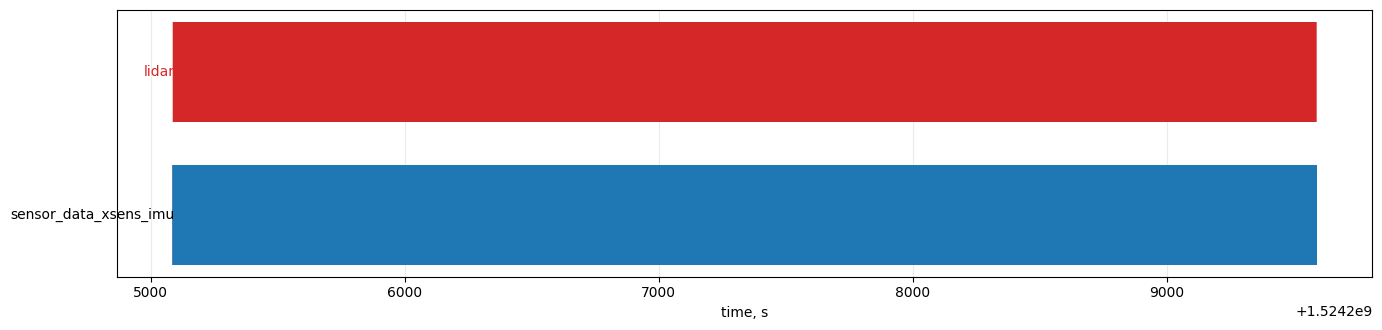

In [21]:
fig, axis = plot_sensor_timestamps(imu_streams, lidar_data)
plt.show()

# True trajectory

In [22]:
DATASET_ROOT

PosixPath('/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16')

In [23]:
import calib_observability.plotting

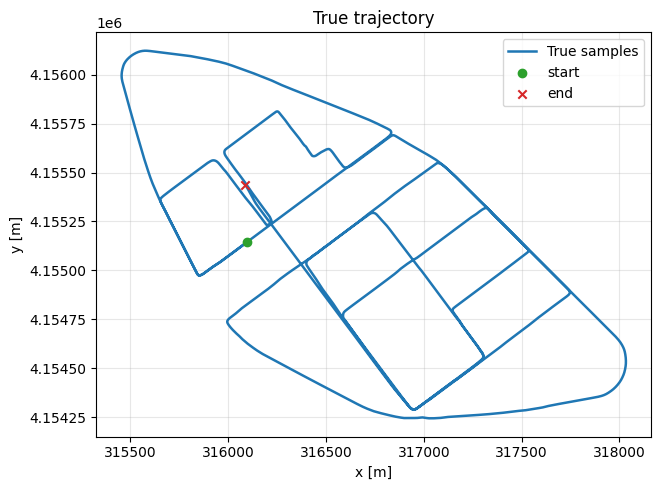

In [24]:
true_timestamps, true_trajectory = kaist_dataset.data.import_true_trajectory(DATASET_ROOT / "urban16_pose/urban16/global_pose.csv")
fig, axis = calib_observability.plotting.plot_trajectory_2d(
    true_trajectory,
    title="True trajectory",
    label="True samples",)